# Exploratory Data Analysis on SOA Mortality Experience Data
## Setup 
### Import Python Packages 

In [1]:
# External packages
import pandas as pd
import numpy as np
import sys
from pprint import pprint

# import random
# import os

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import duckdb

# Internal packages
sys.path.append("../")
from src import utils

pd.set_option("display.max_columns", 100)
duckdb.execute("PRAGMA enable_progress_bar=false")

### Set Variables

In [2]:
# Fontsize for visualisation
tick_fontsize = 14
label_fontsize = 18
title_fontsize = 22

# Define the exposure and death counts (both actual and expected)
exposure = "Policies_Exposed"
act_death = "Death_Count"
exp_death = "ExpDth_VBT2015_Cnt"
exp_death_mi = "ExpDth_VBT2015wMI_Cnt"

## Construct Summary Statistics
### Before vs After Filtering

In [3]:
#######################################################
#######################################################


input_file = "input/ILEC_2012_19 - 20240429.txt"

#######################################################
#######################################################

# Check out the first 5 rows
df_sample = pd.read_csv(input_file, nrows=5, delimiter="\t")
df_sample

,Observation_Year,Age_Ind,Sex,Smoker_Status,Insurance_Plan,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,SOA_Antp_Lvl_TP,SOA_Guar_Lvl_TP,SOA_Post_Lvl_Ind,Slct_Ult_Ind,Preferred_Indicator,Number_of_Pfd_Classes,Preferred_Class,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015_Amt,ExpDth_VBT2015wMI_Cnt,ExpDth_VBT2015wMI_Amt,Cen2MomP1wMI_Amt,Cen2MomP2wMI_Amt,Cen3MomP1wMI_Amt,Cen3MomP2wMI_Amt,Cen3MomP3wMI_Amt
0,2012,ALB,M,NS,Term,34,17,"05: 100,000 - 249,999",1996,50,20 yr anticipated,20 yr guaranteed,WLT,S,1,2,2,2.057949e+06,15.261494,0,0,0.023350,3148.662354,0.023803,3209.731689,473956928,7.392187e+05,76084968161280,118667812864,1.850832e+08
1,2012,ALB,M,NS,Term,34,17,"05: 100,000 - 249,999",1996,50,20 yr anticipated,20 yr guaranteed,WLT,S,1,4,2,5.342400e+03,0.035616,0,0,0.000054,8.173872,0.000056,8.332407,1249861,1.949377e+03,187479146496,292406496,4.560591e+05
2,2012,ALB,M,NS,Term,34,17,"06: 250,000 - 499,999",1995,50,5 yr anticipated,5 yr guaranteed,PLT,S,1,2,1,8.354205e+06,30.044382,0,0,0.045968,12781.933594,0.046859,13029.843750,3722660608,5.806140e+06,1100195399991296,1715947044864,2.676319e+09
3,2012,ALB,M,NS,Term,34,17,"06: 250,000 - 499,999",1995,50,10 yr anticipated,10 yr guaranteed,PLT,S,1,2,2,1.030355e+06,4.095629,0,0,0.006266,1576.443726,0.006388,1607.019287,404369632,6.306851e+05,101772253200384,158731616256,2.475697e+08
4,2012,ALB,M,NS,Term,34,17,"06: 250,000 - 499,999",1995,50,15 yr anticipated,15 yr guaranteed,PLT,S,1,2,2,3.961748e+05,1.584699,0,0,0.002425,606.147339,0.002472,617.903748,154475952,2.409322e+05,38618986971136,60233060352,9.394398e+07


In [4]:
####################################################################
####################################################################

# Columns not required other than higher order moment
col_excluded = ["ExpDth_VBT2015_Amt", "ExpDth_VBT2015wMI_Amt"]

####################################################################
####################################################################

# Check the number of columns and column names
label = f"{len(df_sample.columns)} number of columns"
pprint(f"{label:<30}: {', '.join(list(df_sample.columns))}", width=250)

# Remove those related to higher order central moments - not needed for now
col_list = [x for x in df_sample.columns if x[:3] != "Cen" and x not in col_excluded]
label = f"{len(col_list)} number of required columns"
pprint(f"{label:<30}: {', '.join(col_list)}", width=250)

('30 number of columns          : Observation_Year, Age_Ind, Sex, Smoker_Status, Insurance_Plan, Issue_Age, Duration, Face_Amount_Band, Issue_Year, Attained_Age, SOA_Antp_Lvl_TP, SOA_Guar_Lvl_TP, SOA_Post_Lvl_Ind, Slct_Ult_Ind, Preferred_Indicator, '
 'Number_of_Pfd_Classes, Preferred_Class, Amount_Exposed, Policies_Exposed, Death_Claim_Amount, Death_Count, ExpDth_VBT2015_Cnt, ExpDth_VBT2015_Amt, ExpDth_VBT2015wMI_Cnt, ExpDth_VBT2015wMI_Amt, Cen2MomP1wMI_Amt, Cen2MomP2wMI_Amt, Cen3MomP1wMI_Amt, '
 'Cen3MomP2wMI_Amt, Cen3MomP3wMI_Amt')
('23 number of required columns : Observation_Year, Age_Ind, Sex, Smoker_Status, Insurance_Plan, Issue_Age, Duration, Face_Amount_Band, Issue_Year, Attained_Age, SOA_Antp_Lvl_TP, SOA_Guar_Lvl_TP, SOA_Post_Lvl_Ind, Slct_Ult_Ind, Preferred_Indicator, '
 'Number_of_Pfd_Classes, Preferred_Class, Amount_Exposed, Policies_Exposed, Death_Claim_Amount, Death_Count, ExpDth_VBT2015_Cnt, ExpDth_VBT2015wMI_Cnt')


In [5]:
#####################################################################
#####################################################################

query = f"""
    SELECT 
        COUNT(*) AS row_count
        , SUM(CAST({exposure} AS DOUBLE)) AS exposure
        , SUM(CAST({act_death} AS DOUBLE)) AS act_death_cnt
        , SUM(CAST({exp_death} AS DOUBLE)) AS exp_death_cnt
        , SUM(CAST({exp_death_mi} AS DOUBLE)) AS exp_death_cnt_mi
    FROM read_csv_auto('{input_file}', delim='\t', all_varchar=true)
"""

#####################################################################
#####################################################################

# Check the total exposure, death count and row count in the raw data
result_before = duckdb.query(query).df()
result_before.index = ["Before Filtering"]

# Calculate the actual vs expected frequencies
result_before["act_death_freq"] = (
    result_before["act_death_cnt"] / result_before["exposure"].sum()
)
result_before["exp_death_freq"] = (
    result_before["exp_death_cnt"] / result_before["exposure"].sum()
)
result_before["exp_death_freq_mi"] = (
    result_before["exp_death_cnt_mi"] / result_before["exposure"].sum()
)
result_before

,row_count,exposure,act_death_cnt,exp_death_cnt,exp_death_cnt_mi,act_death_freq,exp_death_freq,exp_death_freq_mi
Before Filtering,45501036,4.645133e+08,4552009.0,4.241620e+06,4.229015e+06,0.0098,0.009131,0.009104


In [6]:
#####################################################################
#####################################################################

query = f"""
    SELECT 
        COUNT(*) AS row_count
        , SUM(CAST({exposure} AS DOUBLE)) AS exposure
        , SUM(CAST({act_death} AS DOUBLE)) AS act_death_cnt
        , SUM(CAST({exp_death} AS DOUBLE)) AS exp_death_cnt
        , SUM(CAST({exp_death_mi} AS DOUBLE)) AS exp_death_cnt_mi
    FROM read_csv_auto('{input_file}', delim='\t', all_varchar=true)
    WHERE CAST(Issue_Age AS INTEGER) BETWEEN 18 AND 80
        AND CAST(Attained_Age AS INTEGER) BETWEEN 18 AND 90
        AND CAST({exposure} AS DOUBLE) > 0
        AND CAST(Issue_Year AS DOUBLE) >= 1980
        AND Insurance_Plan = 'Term'
"""

#####################################################################
#####################################################################

# Check the total exposure, death count and row count after the filtering criteria is applied
result_after = duckdb.query(query).df()
result_after.index = ["After Filtering"]

# Calculate the actual vs expected frequencies
result_after["act_death_freq"] = (
    result_after["act_death_cnt"] / result_after["exposure"].sum()
)
result_after["exp_death_freq"] = (
    result_after["exp_death_cnt"] / result_after["exposure"].sum()
)
result_after["exp_death_freq_mi"] = (
    result_after["exp_death_cnt_mi"] / result_after["exposure"].sum()
)
result_after

,row_count,exposure,act_death_cnt,exp_death_cnt,exp_death_cnt_mi,act_death_freq,exp_death_freq,exp_death_freq_mi
After Filtering,19450868,1.717789e+08,360151.0,332511.704372,330691.535319,0.002097,0.001936,0.001925


In [7]:
################################################################################
################################################################################

# Define formating condition
format_dict = {
    "row_count": "{:,.0f}",
    "exposure": "{:,.0f}",
    "act_death_cnt": "{:,.0f}",
    "exp_death_cnt": "{:,.0f}",
    "exp_death_cnt_mi": "{:,.0f}",
    "act_death_freq": "{:,.4%}",
    "exp_death_freq": "{:,.4%}",
    "exp_death_freq_mi": "{:,.4%}",
}
bar_dict = {
    "row_count": "grey",
    "exposure": "grey",
    "act_death_cnt": "grey",
    "exp_death_cnt": "grey",
    "exp_death_cnt_mi": "grey",
    "act_death_freq": "blue",
    "exp_death_freq": "blue",
    "exp_death_freq_mi": "blue",
}
caption = "Summary Statistics - Before and After Filtering"

################################################################################
################################################################################

# Concatenate the result before and after for comparison
result = pd.concat([result_before, result_after], axis=0)

result.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,row_count,exposure,act_death_cnt,exp_death_cnt,exp_death_cnt_mi,act_death_freq,exp_death_freq,exp_death_freq_mi
Before Filtering,"45,501,036","464,513,252","4,552,009","4,241,620","4,229,015",0.9800%,0.9131%,0.9104%
After Filtering,"19,450,868","171,778,898","360,151","332,512","330,692",0.2097%,0.1936%,0.1925%


### Save the filtered data as a parquet file 
#### Original filtered data 

In [8]:
#####################################################################
#####################################################################

query = f"""
    SELECT 
        CAST(Observation_Year AS INTEGER) AS Observation_Year
        , Age_Ind 
        , Sex 
        , Smoker_Status 
        , Insurance_Plan 
        , CAST(Issue_Age AS INTEGER) AS Issue_Age
        , CAST(Duration AS INTEGER) AS Duration
        , Face_Amount_Band 
        , CAST(Issue_Year AS INTEGER) AS Issue_Year
        , CAST(Attained_Age AS INTEGER) AS Attained_Age
        , SOA_Antp_Lvl_TP
        , SOA_Guar_Lvl_TP	
        , SOA_Post_Lvl_Ind 
        , Slct_Ult_Ind
        , Preferred_Indicator
        , Number_of_Pfd_Classes
        , Preferred_Class
        , CAST(Amount_Exposed AS DOUBLE) AS Amount_Exposed 
        , CAST(Policies_Exposed AS DOUBLE) AS Policies_Exposed
        , CAST(Death_Claim_Amount AS DOUBLE) AS Death_Claim_Amount 
        , CAST(Death_Count AS DOUBLE) AS Death_Count
        , CAST(ExpDth_VBT2015_Cnt AS DOUBLE) AS ExpDth_VBT2015_Cnt
        , CAST(ExpDth_VBT2015wMI_Cnt AS DOUBLE) AS ExpDth_VBT2015wMI_Cnt
    FROM read_csv_auto('{input_file}', delim='\t', all_varchar=true)
    WHERE CAST(Issue_Age AS INTEGER) BETWEEN 18 AND 80
        AND CAST(Attained_Age AS INTEGER) BETWEEN 18 AND 90
        AND CAST({exposure} AS DOUBLE) > 0
        AND CAST(Issue_Year AS DOUBLE) >= 1980
        AND Insurance_Plan = 'Term'
"""

output_file = "export/ILEC_2012_19 - 20240429 (Filtered).parquet"

#####################################################################
#####################################################################

duckdb.query(f"""
    COPY ({query}) TO '{output_file}' (FORMAT PARQUET)
""")

In [9]:
#####################################################################
#####################################################################

query = f"""
    SELECT * FROM read_parquet('{output_file}')
    LIMIT 5
"""

#####################################################################
#####################################################################

# Load in the first 5 rows from the parquet file
db_sample = duckdb.query(f"""{query}""").df()
db_sample

,Observation_Year,Age_Ind,Sex,Smoker_Status,Insurance_Plan,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,SOA_Antp_Lvl_TP,SOA_Guar_Lvl_TP,SOA_Post_Lvl_Ind,Slct_Ult_Ind,Preferred_Indicator,Number_of_Pfd_Classes,Preferred_Class,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt
0,2012,ALB,M,NS,Term,34,17,"05: 100,000 - 249,999",1996,50,20 yr anticipated,20 yr guaranteed,WLT,S,1,2,2,2.057949e+06,15.261494,0.0,0.0,0.023350,0.023803
1,2012,ALB,M,NS,Term,34,17,"05: 100,000 - 249,999",1996,50,20 yr anticipated,20 yr guaranteed,WLT,S,1,4,2,5.342400e+03,0.035616,0.0,0.0,0.000054,0.000056
2,2012,ALB,M,NS,Term,34,17,"06: 250,000 - 499,999",1995,50,5 yr anticipated,5 yr guaranteed,PLT,S,1,2,1,8.354205e+06,30.044382,0.0,0.0,0.045968,0.046859
3,2012,ALB,M,NS,Term,34,17,"06: 250,000 - 499,999",1995,50,10 yr anticipated,10 yr guaranteed,PLT,S,1,2,2,1.030355e+06,4.095629,0.0,0.0,0.006266,0.006388
4,2012,ALB,M,NS,Term,34,17,"06: 250,000 - 499,999",1995,50,15 yr anticipated,15 yr guaranteed,PLT,S,1,2,2,3.961748e+05,1.584699,0.0,0.0,0.002425,0.002472


#### Grouped by All Features

In [10]:
#####################################################################
#####################################################################

query = f"""
    SELECT 
        Observation_Year
        , Age_Ind 
        , Sex 
        , Smoker_Status 
        , Insurance_Plan 
        , Issue_Age
        , Duration
        , Face_Amount_Band 
        , Issue_Year
        , Attained_Age
        , SOA_Antp_Lvl_TP
        , SOA_Guar_Lvl_TP	
        , SOA_Post_Lvl_Ind 
        , Slct_Ult_Ind
        , Preferred_Indicator
        , Number_of_Pfd_Classes
        , Preferred_Class
        , SUM(Amount_Exposed) AS Amount_Exposed  
        , SUM({exposure}) AS {exposure}
        , SUM(Death_Claim_Amount) AS Death_Claim_Amount 
        , SUM({act_death}) AS {act_death}
        , SUM({exp_death}) AS {exp_death}
        , SUM({exp_death_mi}) AS {exp_death_mi}
    FROM read_parquet('{output_file}')
    GROUP BY 
        Observation_Year
        , Age_Ind 
        , Sex 
        , Smoker_Status 
        , Insurance_Plan 
        , Issue_Age
        , Duration
        , Face_Amount_Band 
        , Issue_Year
        , Attained_Age
        , SOA_Antp_Lvl_TP
        , SOA_Guar_Lvl_TP	
        , SOA_Post_Lvl_Ind 
        , Slct_Ult_Ind
        , Preferred_Indicator
        , Number_of_Pfd_Classes
        , Preferred_Class
"""

output_file_gb = "export/ILEC_2012_19 - 20240429 (Filtered and Grouped by All Features).parquet"

#####################################################################
#####################################################################

# Group by risk factors to check if we can reduce the number of rows further
duckdb.query(f"""
    COPY ({query}) TO '{output_file_gb}' (FORMAT PARQUET)
""")

Notice that we can reduce the number of rows further by ~ 1.15m when the data is grouped by its features. 

In [11]:
#####################################################################
#####################################################################

# Define the SQL queries for row counting
query1 = f"""
    SELECT 
        COUNT(*) AS row_count
    FROM read_parquet('{output_file}')
"""

query2 = f"""
    SELECT 
        COUNT(*) AS row_count
    FROM read_parquet('{output_file_gb}')
"""

# Define formating condition
format_dict = {"row_count": "{:,.0f}"}
bar_dict = {"row_count": "grey"}
caption = "Row Count - Before and After Group By"

#####################################################################
#####################################################################

# Get the row count for the parquet before group by
result_before = duckdb.query(query1).df()
result_before.index = ["Before Group By"]

# Get the row count for the parquet after group by
result_after = duckdb.query(query2).df()
result_after.index = ["After Group By"]

# Concatenate the result before and after for comparison
result = pd.concat([result_before, result_after], axis=0)

# Display result
result.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,row_count
Before Group By,"19,450,868"
After Group By,"18,292,049"


#### Check Age_Ind Distribution and Synchronise Attained Age

In [12]:
#####################################################################
#####################################################################

# Define the SQL queries for row counting
var = "Age_Ind"
query = f"""
    SELECT 
        {var}
        , COUNT(*) AS row_count
    FROM read_parquet('{output_file_gb}')
    GROUP BY 
        Age_ind
"""

# Define formating condition
format_dict = {"row_count": "{:,.0f}"}
bar_dict = {"row_count": "grey"}
caption = f"Row Count by {var}"

#####################################################################
#####################################################################

result = duckdb.query(query).df()

# Display result
result.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,Age_Ind,row_count
0,ALB,"7,988,189"
1,ANB,"10,303,860"


We need to transform rows with ANB to ALB. 

In [13]:
#####################################################################
#####################################################################

query = f"""
    SELECT 
        *
        , CASE WHEN Age_Ind = 'ANB' THEN Attained_Age - 1 ELSE Attained_Age END AS Attained_Age_Sync
    FROM read_parquet('{output_file_gb}')
"""

output_file_gb2 = "export/ILEC_2012_19 - 20240429 (Filtered, Grouped by All Features and Synchronised Attained_Age).parquet"

#####################################################################
#####################################################################

# Add the synchronised attained age to the data and export the updated data
duckdb.query(f"""
    COPY ({query}) TO '{output_file_gb2}' (FORMAT PARQUET)
""")

In [14]:
#####################################################################
#####################################################################

# Define the SQL queries for row counting
query = f"""
    WITH dum AS (
        SELECT 
            *
            , Attained_Age_Sync - Attained_Age AS attained_age_diff  
        FROM read_parquet('{output_file_gb2}')
    )
    SELECT 
        {var}
        , attained_age_diff
        , COUNT(*) AS row_count
    FROM dum
    GROUP BY 
         {var}
        , attained_age_diff
"""

# Define formating condition
format_dict = {"row_count": "{:,.0f}"}
bar_dict = {"row_count": "grey"}
caption = f"Row Count by {var} and Diff between Synchronised and Original Attained Age"

#####################################################################
#####################################################################


result = duckdb.query(query).df()

# Display result
result.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,Age_Ind,attained_age_diff,row_count
0,ANB,-1,"10,303,860"
1,ALB,0,"7,988,189"


#### Further Aggregation by Designated Features

In [15]:
###########################################################
###########################################################

feat_list = [
    "Observation_Year",
    "Sex",
    "Smoker_Status",
    "Insurance_Plan",
    "Duration",
    "Face_Amount_Band",
    "Attained_Age_Sync",
]

query = f"""
    SELECT 
        {", ".join(feat_list)}
        , SUM(Amount_Exposed) AS Amount_Exposed  
        , SUM({exposure}) AS {exposure}
        , SUM(Death_Claim_Amount) AS Death_Claim_Amount 
        , SUM({act_death}) AS {act_death}
        , SUM({exp_death}) AS {exp_death}
        , SUM({exp_death_mi}) AS {exp_death_mi}
    FROM read_parquet('{output_file_gb2}')
    GROUP BY 
        {", ".join(feat_list)}
"""

output_file_gb3 = (
    "export/ILEC_2012_19 - 20240429 (Filtered, Synchronised Attained_Age and Grouped by Selected Features).parquet"
)

###########################################################
###########################################################

# Add the synchronised attained age to the data and export the updated data
duckdb.query(f"""
    COPY ({query}) TO '{output_file_gb3}' (FORMAT PARQUET)
""")

In [16]:
#####################################################################
#####################################################################

# Define the SQL queries for row counting
query1 = f"""
    SELECT 
        COUNT(*) AS row_count
        , SUM({exposure}) AS {exposure}
        , SUM({act_death}) AS {act_death}
        , SUM({exp_death}) AS {exp_death}
        , SUM({exp_death_mi}) AS {exp_death_mi}
    FROM read_parquet('{output_file}')
"""

query2 = f"""
    SELECT 
        COUNT(*) AS row_count
        , SUM({exposure}) AS {exposure}
        , SUM({act_death}) AS {act_death}
        , SUM({exp_death}) AS {exp_death}
        , SUM({exp_death_mi}) AS {exp_death_mi}
    FROM read_parquet('{output_file_gb}')
"""

query3 = f"""
    SELECT 
        COUNT(*) AS row_count  
        , SUM({exposure}) AS {exposure}
        , SUM({act_death}) AS {act_death}
        , SUM({exp_death}) AS {exp_death}
        , SUM({exp_death_mi}) AS {exp_death_mi}
    FROM read_parquet('{output_file_gb3}')
"""

# Define formating condition
format_dict = {
    "row_count": "{:,.0f}",
    exposure: "{:,.0f}",
    act_death: "{:,.0f}",
    exp_death: "{:,.0f}",
    exp_death_mi: "{:,.0f}",
}
bar_dict = {
    "row_count": "grey",
    exposure: "grey",
    act_death: "grey",
    exp_death: "grey",
    exp_death_mi: "grey",
}
caption = "Row Count - Before and After Group By"

#####################################################################
#####################################################################

# Get the row count for the parquet before group by
result_before = duckdb.query(query1).df()
result_before.index = ["Before Group By"]

# Get the row count for the parquet after group by
result_after2 = duckdb.query(query2).df()
result_after2.index = ["After First Group By"]

result_after3 = duckdb.query(query3).df()
result_after3.index = ["After Second Group By"]

# Concatenate the result before and after for comparison
result = pd.concat([result_before, result_after2, result_after3], axis=0)

# Display result
result.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,row_count,Policies_Exposed,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt
Before Group By,"19,450,868","171,778,898","360,151","332,512","330,692"
After First Group By,"18,292,049","171,778,898","360,151","332,512","330,692"
After Second Group By,"575,754","171,778,898","360,151","332,512","330,692"


### Perform one-way risk trend analysis

In [17]:
# Import the final aggregated data
df = pd.read_parquet(output_file_gb3)
df

,Observation_Year,Sex,Smoker_Status,Insurance_Plan,Duration,Face_Amount_Band,Attained_Age_Sync,Amount_Exposed,Policies_Exposed,Death_Claim_Amount,Death_Count,ExpDth_VBT2015_Cnt,ExpDth_VBT2015wMI_Cnt
0,2012,M,NS,Term,7,"10: 5,000,000 - 9,999,999",53,4.769294e+08,85.221704,0.0,0.0,0.128005,0.130487
1,2012,M,NS,Term,10,"11: 10,000,000+",59,1.964895e+08,16.607149,0.0,0.0,0.050614,0.051595
2,2012,M,NS,Term,11,"06: 250,000 - 499,999",48,1.988205e+09,6664.746140,2050000.0,8.0,7.494563,7.639922
3,2012,M,NS,Term,7,"04: 50,000 - 99,999",53,1.419839e+07,227.479668,75000.0,1.0,0.341435,0.348057
4,2012,M,NS,Term,6,"02: 10,000 - 24,999",55,2.500000e+05,13.977978,0.0,0.0,0.024675,0.025154
...,...,...,...,...,...,...,...,...,...,...,...,...,...
575749,2015,F,S,Term,19,"01: 0 - 9,999",88,5.109048e+02,0.304110,0.0,0.0,0.038315,0.038315
575750,2019,M,S,Term,24,"07: 500,000 - 999,999",70,1.835616e+05,0.367123,0.0,0.0,0.010632,0.010363
575751,2012,F,S,Term,26,"06: 250,000 - 499,999",68,7.718575e+04,0.308743,0.0,0.0,0.006070,0.006158
575752,2015,M,NS,Term,31,"09: 2,500,000 - 4,999,999",66,2.117475e+05,0.084699,0.0,0.0,0.000713,0.000713


In [ ]:
def risk_agg(
    df: pd.DataFrame, var: str, exposure: str, act_death_count: str, **kwarg
) -> pd.DataFrame:
    """
    Aggregate risk metrics by a grouping variable and calculate death/event rates.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing risk data.
    var : str
        Column name to group by.
    exposure : str
        Column name for exposure values.
    act_death_count : str
        Column name for actual death counts.
    **kwarg : str
        Additional count columns to aggregate and convert to rates.

    Returns
    -------
    pd.DataFrame
        Aggregated DataFrame
    """

    agg_dict = {exposure: "sum", act_death_count: "sum"}
    for _, v in kwarg.items():
        agg_dict[v] = "sum"
    df_agg = df.groupby(var, dropna=False).agg(agg_dict)
    df_agg["actual_death_rate"] = df_agg[act_death_count] / df_agg[exposure]

    for k, v in kwarg.items():
        df_agg[k.replace("count", "rate")] = df_agg[v] / df_agg[exposure]

    return df_agg


def save_risk_agg_to_excel(risk_agg_dict: dict, filepath: str):
    """
    Save each DataFrame in the dict to a separate sheet in an Excel file.

    Parameters
    ----------
    risk_agg_dict : dict
        Dictionary where keys are sheet names and values are DataFrames.
    filepath : str
        Output Excel file path.
    """
    with pd.ExcelWriter(filepath, engine="openpyxl") as writer:
        for sheet_name, df in risk_agg_dict.items():
            df.to_excel(writer, sheet_name=sheet_name)

In [ ]:
##################################################################
##################################################################

key_features = [
    "Observation_Year",
    "Sex",
    "Smoker_Status",
    "Duration",
    "Face_Amount_Band",
    "Attained_Age_Sync",
]

output_file = "output/risk_agg_by_key_features.xlsx"

##################################################################
##################################################################

# Initialise an empty dict for holding the grouped by dataframes 
risk_agg_dict = {}

for v in key_features: 

    # Perform risk aggregations by individual features
    df_gb = utils.risk_agg(
        df,
        v,
        exposure,
        act_death,
        exp_death_count=exp_death,
        expected_death_count_mi=exp_death_mi,
    )
    risk_agg_dict[v] = df_gb 

# Export the risk agg by each feature to a tab in a spreadsheet 
utils.save_risk_agg_to_excel(risk_agg_dict, output_file)

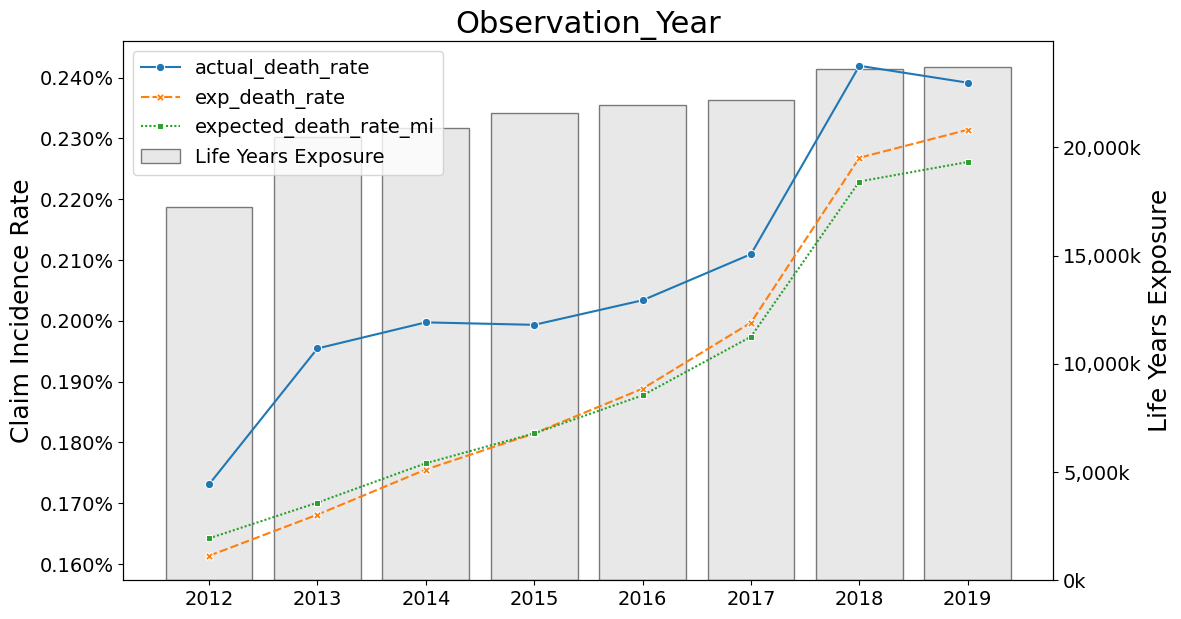

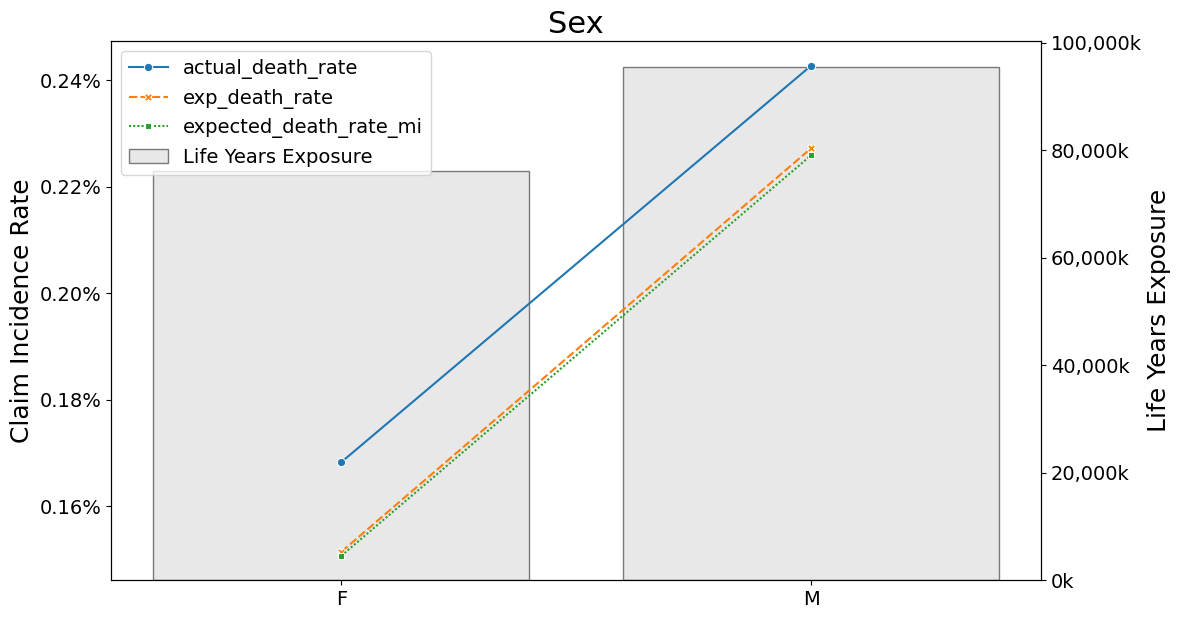

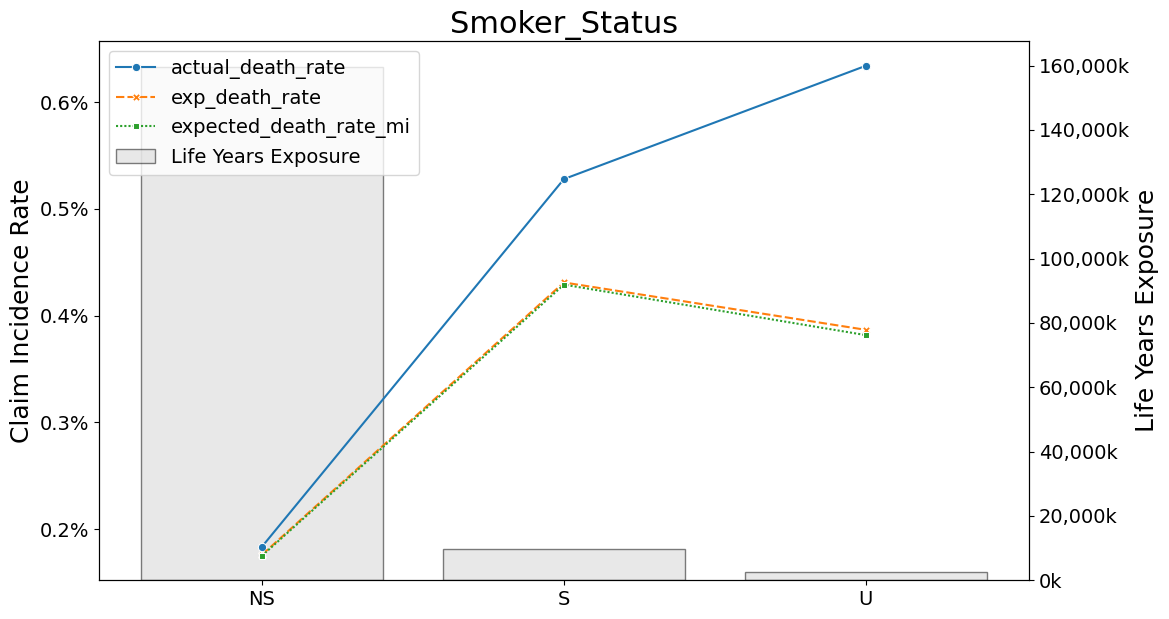

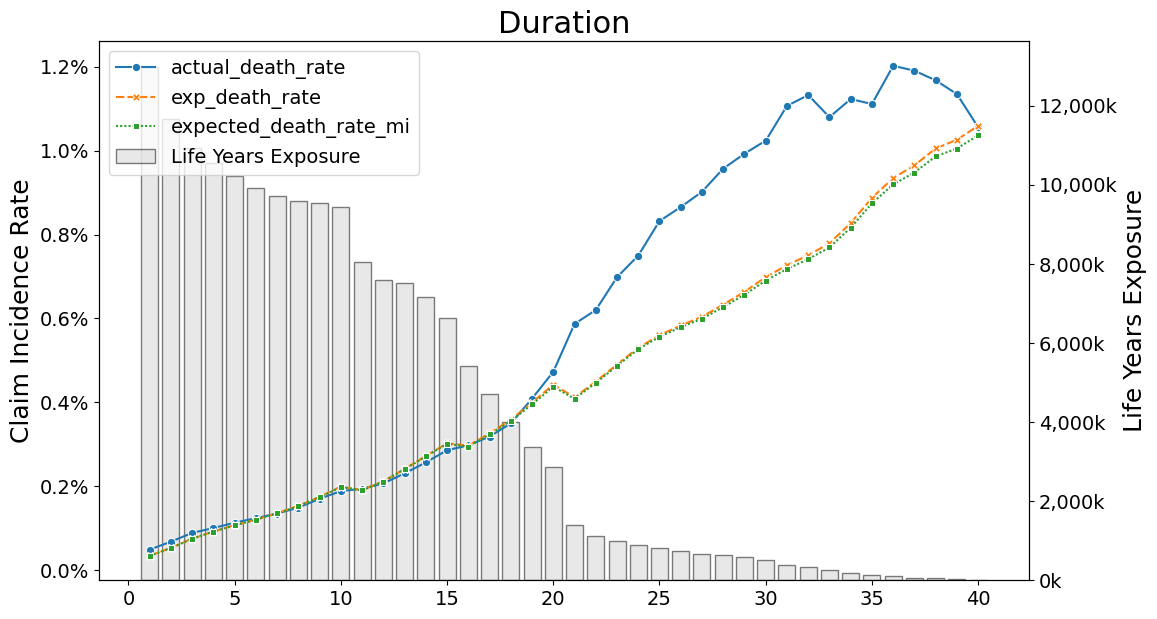

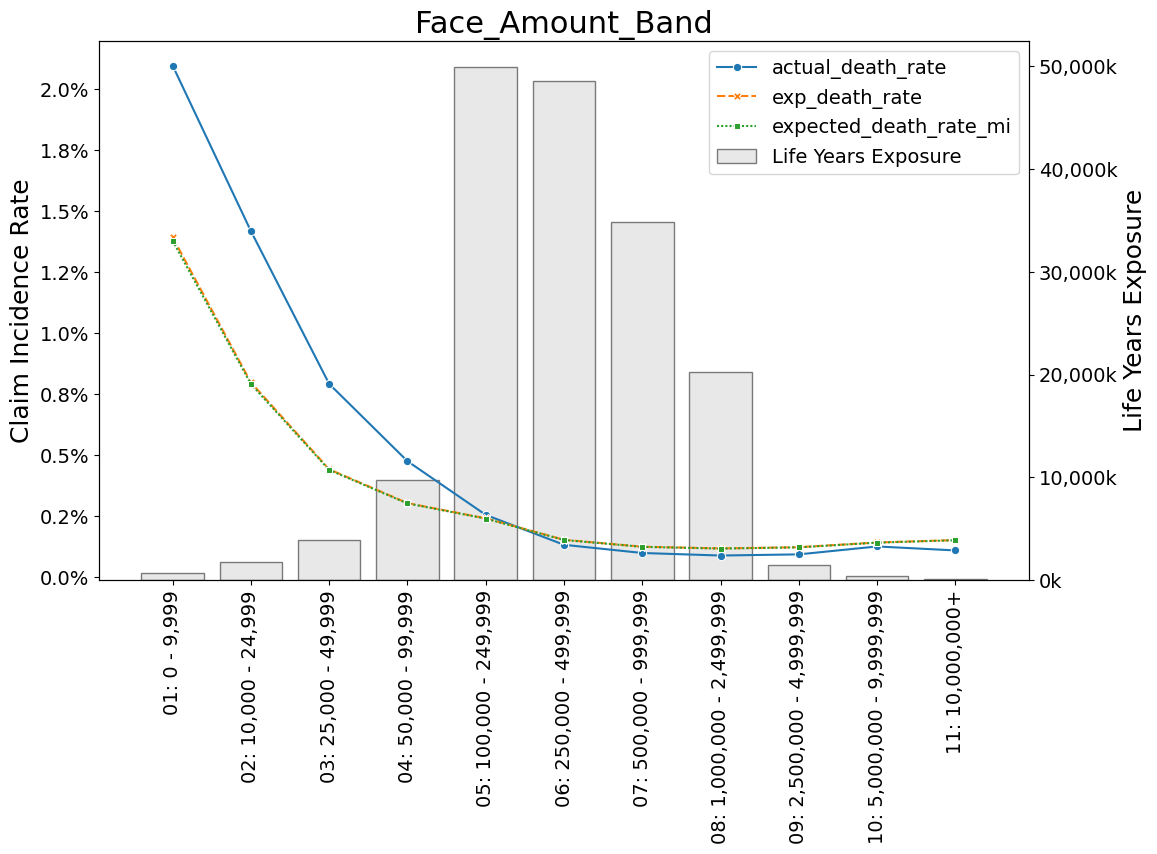

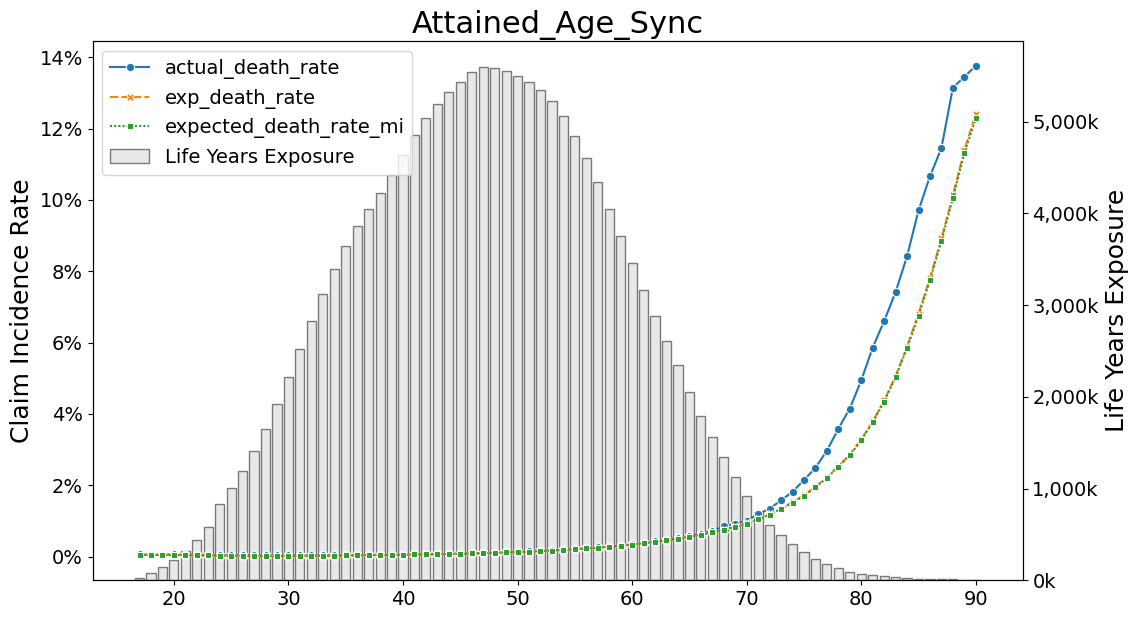

In [ ]:
##############################################################################################
##############################################################################################

y1_label = "Claim Incidence Rate"
y2_label = "Life Years Exposure"

##############################################################################################
##############################################################################################

for var in key_features:
    
    fig, ax = plt.subplots(1, figsize=(12, 7))
    # Plot incidence rates
    sns.lineplot(
        data=risk_agg_dict[var].loc[
            :, [x for x in risk_agg_dict[var].columns if "_rate" in x]
        ],
        ax=ax,
        markers=True,
    )

    # Set title and x and y axes labels and fontsize
    ax.set_ylabel(y1_label, fontsize=label_fontsize)
    ax.set_xlabel("")
    ax.set_title(var, fontsize=title_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

    # Formate y-axis tickers
    yticks = ax.get_yticks()
    diff = np.min(np.diff(yticks))
    dp = utils.round_down_to_power_of_10(diff)
    dp = int(max(np.abs(np.log10(dp)) - 2, 0))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _, dp=dp: f"{x:.{dp}%}"))
    
    # Format x-axis tickers
    ax.tick_params(
        axis="x",
        rotation=(
            90
            if isinstance(risk_agg_dict[var].index[0], str)
            and len(risk_agg_dict[var].index[0]) > 4
            else 0
        ),
    )

    # Create secondary y-axis for exposures
    ax2 = ax.twinx()
    ax2.bar(
        risk_agg_dict[var].index,
        risk_agg_dict[var][exposure],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=y2_label,
    )

    # Format secondary y-axis ticker 
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=tick_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=tick_fontsize,
        facecolor="white",
    )

    # Set secondary y-axis label
    ax2.set_ylabel(y2_label, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)